In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import h5flow
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from matplotlib.colors import LogNorm
import datetime, pytz

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"


In [2]:
# DUNE plot style
import sys; sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "..", "utils"))
from dune_plot import apply_dune_style, dune_label
apply_dune_style()

## Helper functions (thd_correct, aggregation, TRAP_NAME_MAP)

In [3]:
from dtg_utils import (
    thd_correct, TRAP_NAME_MAP, sum_to_traps,
    get_trap_indices, reject_saturation,
    compute_fprompt_fixed, detect_pileup_rising_tail, calibrate_energy_mev,
    SAT_THRESHOLD, PEAK_TICK_FIXED, PILEUP_LOOKBACK, PILEUP_TAIL_REL_HEIGHT,
    LCM_ENERGY_NORM, ENERGY_SCALE, N_MODULES,
    NEARLINE_DIR, AR41_HALF_LIFE,
)

acl_idx, acl_tpc = get_trap_indices("acl")
lcm_idx, lcm_tpc = get_trap_indices("lcm")
print(f"ACL traps (excl. TPC 6): {len(acl_idx)},  LCM traps (excl. TPC 6): {len(lcm_idx)}")

ACL traps (excl. TPC 6): 28,  LCM traps (excl. TPC 6): 28


## File catalogue — map every file to its UTC and Chicago timestamp

In [4]:
DATA_FOLDER = NEARLINE_DIR
chicago = pytz.timezone("America/Chicago")

all_files = sorted(
    os.path.join(DATA_FOLDER, f)
    for f in os.listdir(DATA_FOLDER)
    if f.endswith(".hdf5")
)
print(f"Total files found: {len(all_files)}")

Total files found: 1517


In [4]:

i = 0
# Read the first event's timestamp from each file — fast (single read per file)
catalogue = []  # list of (path, t_chicago, n_events)
for path in all_files:
    if i % 100 == 0:
        print(f"Processing file {i}/{len(all_files)}: {os.path.basename(path)}")
    i += 1
    try:
        with h5py.File(path, "r") as h:
            utime_ms = h["light/events/data"]["utime_ms"]
            if len(utime_ms) == 0:
                continue
            t_unix_s = float(utime_ms[0][0]) / 1e3
            t_chicago = datetime.datetime.fromtimestamp(t_unix_s, tz=chicago)
            n_ev = len(utime_ms)
        catalogue.append({"path": path, "t_chicago": t_chicago, "n_events": n_ev})
    except Exception as e:
        print(f"  Skipping {os.path.basename(path)}: {e}")


Processing file 0/1517: mpd_run_data_rctl_978_p0.FLOW.hdf5


KeyboardInterrupt: 

In [ ]:

cat_df = pd.DataFrame(catalogue).sort_values("t_chicago").reset_index(drop=True)
print(f"Files catalogued: {len(cat_df)}")
print(f"Start : {cat_df['t_chicago'].iloc[0]}")
print(f"End   : {cat_df['t_chicago'].iloc[-1]}")
print(f"Total events: {cat_df['n_events'].sum():,}")


Files catalogued: 1517
Start : 2025-12-12 17:56:39.516000-06:00
End   : 2025-12-13 16:43:41.950000-06:00
Total events: 6,405,670


In [5]:
# Save the catalogue for later use (skip the 11-minute build next time)
# cat_df.to_csv("dtg_file_catalogue.csv", index=False)

# To reload without rebuilding:
cat_df = pd.read_csv("dtg_file_catalogue.csv")
cat_df["t_chicago"] = pd.to_datetime(cat_df["t_chicago"], format="ISO8601").dt.tz_convert(chicago)


In [6]:
cat_df.head(20)

,path,t_chicago,n_events
0,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,2025-12-12 17:56:39.516000-06:00,2801
1,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,2025-12-12 17:56:53.502000-06:00,6043
2,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,2025-12-12 17:57:23.697000-06:00,6039
3,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,2025-12-12 17:57:53.848000-06:00,6040
4,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,2025-12-12 17:58:24.006000-06:00,6038
5,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,2025-12-12 17:58:54.155000-06:00,6034
6,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,2025-12-12 17:59:24.306000-06:00,6048
7,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,2025-12-12 17:59:54.498000-06:00,6043
8,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,2025-12-12 18:00:24.657000-06:00,6042
9,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,2025-12-12 18:00:54.822000-06:00,6034


## Define time windows

In [7]:
# DTG turns off after the first ~30 minutes of external triggers.
# Edit DTG_OFF to the actual switchover time once you've seen the catalogue.
DTG_OFF = datetime.datetime(2025, 12, 12, 17, 36, 0, tzinfo=chicago) # Should be 17:36 according to the run log

# Good spike-free windows identified from the rate monitor plot.
# Each entry: (label, centre_time_chicago).  We'll take ±1 min around each centre.
# For the long clean stretch (1:15–3:15) we add several 2-min windows.
WINDOW_HALF = datetime.timedelta(minutes=2)  # ±1 min → 2-min windows

good_windows = [
    # label,   centre time (Chicago)
    # ("t036m",  datetime.datetime(2025, 12, 12, 18,  6, 0, tzinfo=chicago)),
    # ("t060m",  datetime.datetime(2025, 12, 12, 18, 36, 0, tzinfo=chicago)), # too much spiking in the 18:30–18:40 range
    ("t069m",  datetime.datetime(2025, 12, 12, 18, 45, 0, tzinfo=chicago)),
    ("t099m",  datetime.datetime(2025, 12, 12, 19, 15, 0, tzinfo=chicago)),
    ("t129m",  datetime.datetime(2025, 12, 12, 19, 45, 0, tzinfo=chicago)),
    ("t189m",  datetime.datetime(2025, 12, 12, 20, 45, 0, tzinfo=chicago)),
    ("t219m",  datetime.datetime(2025, 12, 12, 21, 15, 0, tzinfo=chicago)),
    ("t264m",  datetime.datetime(2025, 12, 12, 22,  0, 0, tzinfo=chicago)),
    ("t309m",  datetime.datetime(2025, 12, 12, 22, 45, 0, tzinfo=chicago)),
    ("t399m",  datetime.datetime(2025, 12, 13,  0, 15, 0, tzinfo=chicago)),
    ("t459m",  datetime.datetime(2025, 12, 13,  1, 15, 0, tzinfo=chicago)),
    ("t519m",  datetime.datetime(2025, 12, 13,  2, 15, 0, tzinfo=chicago)),
    ("t564m",  datetime.datetime(2025, 12, 13,  3, 0, 0, tzinfo=chicago)),
    ("t699m",  datetime.datetime(2025, 12, 13,  5, 15, 0, tzinfo=chicago)),
    ("t759m",  datetime.datetime(2025, 12, 13,  6, 15, 0, tzinfo=chicago))
]

# Map each window to the files that fall inside it
def files_in_window(centre, half=WINDOW_HALF):
    lo = centre - half
    hi = centre + half
    return cat_df[(cat_df["t_chicago"] >= lo) & (cat_df["t_chicago"] < hi)]["path"].tolist()

for label, centre in good_windows:
    paths = files_in_window(centre)
    dt_min = (centre - DTG_OFF).total_seconds() / 60
    print(f"{label:15s}  Δt={dt_min:+7.1f} min   files={len(paths):3d}  "
          f"events≈{sum(cat_df[cat_df['path'].isin(paths)]['n_events'])}")


t069m            Δt=  +69.0 min   files=  8  events≈34270
t099m            Δt=  +99.0 min   files=  4  events≈19874
t129m            Δt= +129.0 min   files=  4  events≈18112
t189m            Δt= +189.0 min   files=  4  events≈16307
t219m            Δt= +219.0 min   files=  4  events≈15586
t264m            Δt= +264.0 min   files=  4  events≈14671
t309m            Δt= +309.0 min   files=  4  events≈13896
t399m            Δt= +399.0 min   files=  4  events≈12769
t459m            Δt= +459.0 min   files=  4  events≈12248
t519m            Δt= +519.0 min   files=  4  events≈11916
t564m            Δt= +564.0 min   files=  4  events≈11500
t699m            Δt= +699.0 min   files=  4  events≈11178
t759m            Δt= +759.0 min   files=  4  events≈11163


## Processing function — returns per-trap fprompt and integral arrays

In [8]:
DETECTOR   = "lcm"  # "lcm" or "acl"
CHUNK_SIZE = 300


def process_files(paths, chunk_size=CHUNK_SIZE):
    """
    Process HDF5 files in memory-safe chunks with a fixed peak position.
    Uses shared utilities from dtg_utils for baseline correction, trap
    aggregation, fprompt, and pileup detection.
    """
    fp_acl, en_acl, np_acl = [], [], []
    fp_lcm, en_lcm, np_lcm = [], [], []
    livetime_s = 0.0

    for path in paths:
        with h5py.File(path, "r") as h:
            utime_ms = h["light/events/data"]["utime_ms"]
            n_total  = len(utime_ms)
            if n_total >= 2:
                livetime_s += (float(utime_ms[-1][0]) - float(utime_ms[0][0])) / 1e3
            wvfm_ds = h["/light/wvfm/data"]["samples"]

            for start in range(0, n_total, chunk_size):
                stop = min(start + chunk_size, n_total)

                raw        = wvfm_ds[start:stop, :, :, :500]
                samples    = thd_correct(raw.astype(np.float32)); del raw
                saturated  = reject_saturation(samples, SAT_THRESHOLD)
                trap_wvfms = sum_to_traps(samples, TRAP_NAME_MAP).astype(np.float32); del samples

                trap_fprompts, trap_integrals = compute_fprompt_fixed(trap_wvfms, PEAK_TICK_FIXED)
                n_peaks_traps = detect_pileup_rising_tail(
                    trap_wvfms, PEAK_TICK_FIXED, PILEUP_LOOKBACK, PILEUP_TAIL_REL_HEIGHT
                )
                del trap_wvfms

                good = ~saturated
                fp_acl.append(trap_fprompts[good][:, acl_idx])
                en_acl.append(trap_integrals[good][:, acl_idx])
                np_acl.append(n_peaks_traps[good][:, acl_idx])
                fp_lcm.append(trap_fprompts[good][:, lcm_idx])
                en_lcm.append(trap_integrals[good][:, lcm_idx])
                np_lcm.append(n_peaks_traps[good][:, lcm_idx])

    def cat(lst): return np.concatenate(lst, axis=0) if lst else np.array([]).reshape(0, 0)
    return {
        "fprompt_acl": cat(fp_acl), "energy_acl": cat(en_acl), "n_peaks_acl": cat(np_acl),
        "fprompt_lcm": cat(fp_lcm), "energy_lcm": cat(en_lcm), "n_peaks_lcm": cat(np_lcm),
        "livetime_s":  livetime_s,
    }

## Process all windows  *(runs in a few minutes)*

/global/u2/m/mnuland/backtracking/2x2_neutron_sources/DTG/light/dtg_utils.py:199: RuntimeWarning: Mean of empty slice
  average_mean = np.nanmean(sorted_means[..., 1:3], axis=-1)


Peak tick in average waveform: 81


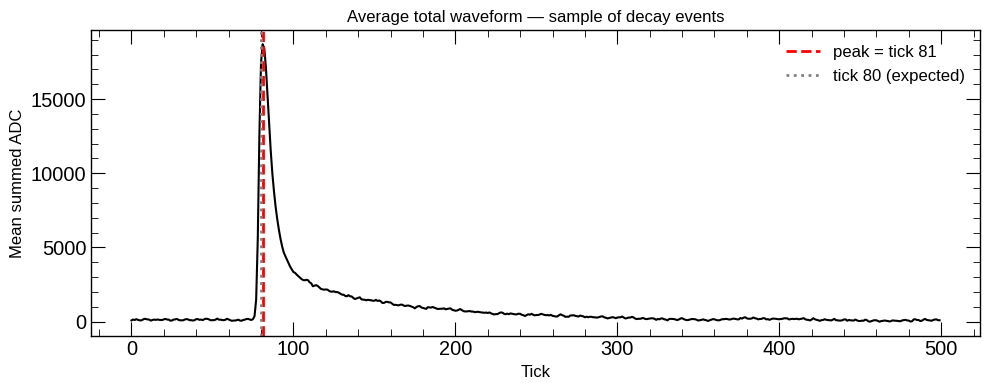

In [9]:
# Quick check: average total waveform over a sample of events from one file.
# This confirms the expected peak position before we hard-code it.

N_CHECK = 500   # events to average

sample_path = files_in_window(dict(good_windows)["t069m"])[0]
wvfm_sum = None
n_used = 0

with h5py.File(sample_path, "r") as h:
    raw = h["/light/wvfm/data"]["samples"][:N_CHECK, :, :, :500].astype(np.float32)

samples    = thd_correct(raw); del raw
trap_wvfms = sum_to_traps(samples, TRAP_NAME_MAP).astype(np.float32); del samples
total_wvfm = trap_wvfms.sum(axis=1)   # (n_ev, 500)

avg_wvfm = total_wvfm.mean(axis=0)
peak_tick = int(avg_wvfm.argmax())
print(f"Peak tick in average waveform: {peak_tick}")

plt.figure(figsize=(10, 4))
plt.plot(avg_wvfm, lw=1.5)
plt.axvline(peak_tick, color="red", ls="--", label=f"peak = tick {peak_tick}")
plt.axvline(80, color="gray", ls=":", label="tick 80 (expected)")
plt.xlabel("Tick", fontsize=12)
plt.ylabel("Mean summed ADC", fontsize=12)
plt.title("Average total waveform — sample of decay events", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
# Interactive waveform browser — shows only (event, trap) pairs with a real signal.
# Pairs are pre-filtered by peak height at PEAK_TICK_FIXED so you never scroll through noise.

import ipywidgets as widgets
from IPython.display import display

# Fixed-window slices (matching process_files)
_prompt_slice = slice(PEAK_TICK_FIXED - 5, PEAK_TICK_FIXED + 10)   # 15 ticks
_total_slice  = slice(PEAK_TICK_FIXED - 5, PEAK_TICK_FIXED + 195)  # 200 ticks

# ── Settings ──────────────────────────────────────────────────────────────
INSPECT_WINDOW = "t069m"   # any label from good_windows
N_INSPECT      = 80        # events to load from the file
MIN_PEAK_ADC   = 10000       # minimum trap peak height (ADC counts) to show
# ──────────────────────────────────────────────────────────────────────────

inspect_path = files_in_window(dict(good_windows)[INSPECT_WINDOW])[0]
print(f"Loading {N_INSPECT} events from:\n  {inspect_path}")

with h5py.File(inspect_path, "r") as h:
    raw = h["/light/wvfm/data"]["samples"][:N_INSPECT, :, :, :500]

samples    = thd_correct(raw.astype(np.float32))
trap_wvfms = sum_to_traps(samples, TRAP_NAME_MAP).astype(np.float32)  # (N, 64, 500)

# Per-trap quantities
_fp_num = trap_wvfms[:, :, _prompt_slice].sum(axis=-1)
_fp_den = trap_wvfms[:, :, _total_slice ].sum(axis=-1)
_fp_all = _fp_num / np.where(_fp_den != 0, _fp_den, np.nan)
_en_all = _fp_den * 0.004 * 0.01   # PE (reuse total-window integral)

from scipy.signal import find_peaks as _find_peaks

# ── Pre-filter: keep only (event, trap) pairs above MIN_PEAK_ADC ──────────
peak_height = trap_wvfms[:, :, PEAK_TICK_FIXED]          # (N, 64)
ev_idx, tr_idx = np.where(peak_height >= MIN_PEAK_ADC)

if len(ev_idx) == 0:
    print(f"No pairs found above {MIN_PEAK_ADC} ADC — lower MIN_PEAK_ADC.")
else:
    print(f"Found {len(ev_idx)} (event, trap) pairs above {MIN_PEAK_ADC} ADC counts.")

    t_us = np.arange(500) * 0.016   # µs (16 ns/tick)

    def _plot(pair_i):
        ev  = ev_idx[pair_i]
        tr  = tr_idx[pair_i]
        info = TRAP_NAME_MAP[tr]
        wvfm = trap_wvfms[ev, tr, :]
        fp   = _fp_all[ev, tr]
        en   = _en_all[ev, tr]
        pk   = peak_height[ev, tr]
        # Count peaks in the total window with scipy.find_peaks
        w_win = trap_wvfms[ev, tr, _total_slice]
        _pks, _ = _find_peaks(w_win,
                               height=PILEUP_TAIL_REL_HEIGHT * pk,
                               distance=5)
        np_ = max(len(_pks), 1)

        fig, ax = plt.subplots(figsize=(13, 4))
        ax.plot(t_us, wvfm, color="k", marker='o', lw=1.2)

        ax.axvspan(t_us[_prompt_slice.start], t_us[_prompt_slice.stop - 1],
                   alpha=0.25, color="tab:blue",   label="prompt")
        ax.axvspan(t_us[_prompt_slice.stop],  t_us[_total_slice.stop  - 1],
                   alpha=0.10, color="tab:orange", label="total (rest)")
        ax.axvline(t_us[PEAK_TICK_FIXED], ls=":", color="gray", lw=1)
        ax.axhline(PILEUP_TAIL_REL_HEIGHT * trap_wvfms[ev, tr, PEAK_TICK_FIXED],
                   ls="--", color="tab:red", lw=1, label="pileup threshold")

        fp_str = f"{fp:.3f}" if np.isfinite(fp) else "nan"
        ax.set_title(
            f"Pair {pair_i}/{len(ev_idx)-1}  |  Event {ev}, Trap {tr}: {info['name']}  "
            f"(TPC {info['tpc']}, {info['z_side']}, {info['position']})"
            f"peak = {pk:.0f} ADC    fprompt = {fp_str}    "
            f"energy = {en:.2f} MeV (estimate)    n_peaks = {np_}",
            fontsize=11
        )
        ax.set_xlabel("Time (µs)", fontsize=12)
        ax.set_ylabel("ADC counts (baseline-subtracted)", fontsize=12)

        ax.legend(fontsize=10, loc="upper right")
        ax.minorticks_on()
        ax.tick_params(direction="in", which="both")
        plt.tight_layout()
        plt.ylim(0,10)
        plt.show()

    widgets.interact(
        _plot,
        pair_i=widgets.IntSlider(min=0, max=len(ev_idx) - 1, step=1, value=0,
                                 description="Pair #", continuous_update=False,
                                 layout=widgets.Layout(width="70%")),
    )

Loading 80 events from:
  /global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/source_dtg_bin2/two_trig_40us_period_500tick/hv_65kV_beamC_25uA/dtg_30min_thenDecay/mpd_run_data_rctl_979_p7.FLOW.hdf5
Found 44 (event, trap) pairs above 10000 ADC counts.


interactive(children=(IntSlider(value=0, continuous_update=False, description='Pair #', layout=Layout(width='7…

In [11]:
results = {}   # label → dict from process_files()

for label, centre in good_windows:
    paths = files_in_window(centre)
    if not paths:
        print(f"{label}: no files found, skipping")
        continue
    print(f"Processing {label}  ({len(paths)} files) ...", end=" ", flush=True)
    results[label] = process_files(paths)
    r = results[label]
    n_ev = r["fprompt_acl"].shape[0] if r["fprompt_acl"].ndim == 2 else 0
    print(f"done  — {n_ev:,} events  livetime={r['livetime_s']:.1f}s")


Processing t069m  (8 files) ... 

/global/u2/m/mnuland/backtracking/2x2_neutron_sources/DTG/light/dtg_utils.py:275: RuntimeWarning: divide by zero encountered in divide
  fprompt = fprompt_num / fprompt_den


done  — 33,212 events  livetime=242.1s
Processing t099m  (4 files) ... done  — 19,236 events  livetime=243.2s
Processing t129m  (4 files) ... done  — 17,728 events  livetime=243.3s
Processing t189m  (4 files) ... done  — 15,947 events  livetime=242.9s
Processing t219m  (4 files) ... done  — 15,229 events  livetime=242.8s
Processing t264m  (4 files) ... done  — 14,278 events  livetime=242.9s
Processing t309m  (4 files) ... done  — 13,517 events  livetime=242.1s
Processing t399m  (4 files) ... done  — 12,386 events  livetime=240.5s
Processing t459m  (4 files) ... done  — 11,857 events  livetime=240.4s
Processing t519m  (4 files) ... done  — 11,524 events  livetime=240.7s
Processing t564m  (4 files) ... done  — 11,116 events  livetime=240.8s
Processing t699m  (4 files) ... done  — 10,749 events  livetime=241.4s
Processing t759m  (4 files) ... done  — 10,674 events  livetime=240.8s


In [12]:
# Load cosmics background from the matched-flow Run 2 data.
from dtg_utils import COSMIC_DIR

N_COSMIC_FILES = 10   # increase for better statistics; each file takes ~30 s to process

cosmic_files = sorted(
    os.path.join(COSMIC_DIR, f)
    for f in os.listdir(COSMIC_DIR)
    if f.endswith(".hdf5")
)[:N_COSMIC_FILES]

print(f"Processing {len(cosmic_files)} cosmic files for background ...")
bkg_result = process_files(cosmic_files)
print(f"  ACL trap-entries: {len(bkg_result['fprompt_acl']):,}")
print(f"  LCM trap-entries: {len(bkg_result['fprompt_lcm']):,}")
print(f"  Livetime: {bkg_result['livetime_s']:.1f} s")

Processing 10 cosmic files for background ...


/global/u2/m/mnuland/backtracking/2x2_neutron_sources/DTG/light/dtg_utils.py:275: RuntimeWarning: invalid value encountered in divide
  fprompt = fprompt_num / fprompt_den


  ACL trap-entries: 142,237
  LCM trap-entries: 142,237
  Livetime: 7839.2 s


## fprompt vs energy 2D histograms per window

More than 10 windows; plotting every third one (total plotted: 5)


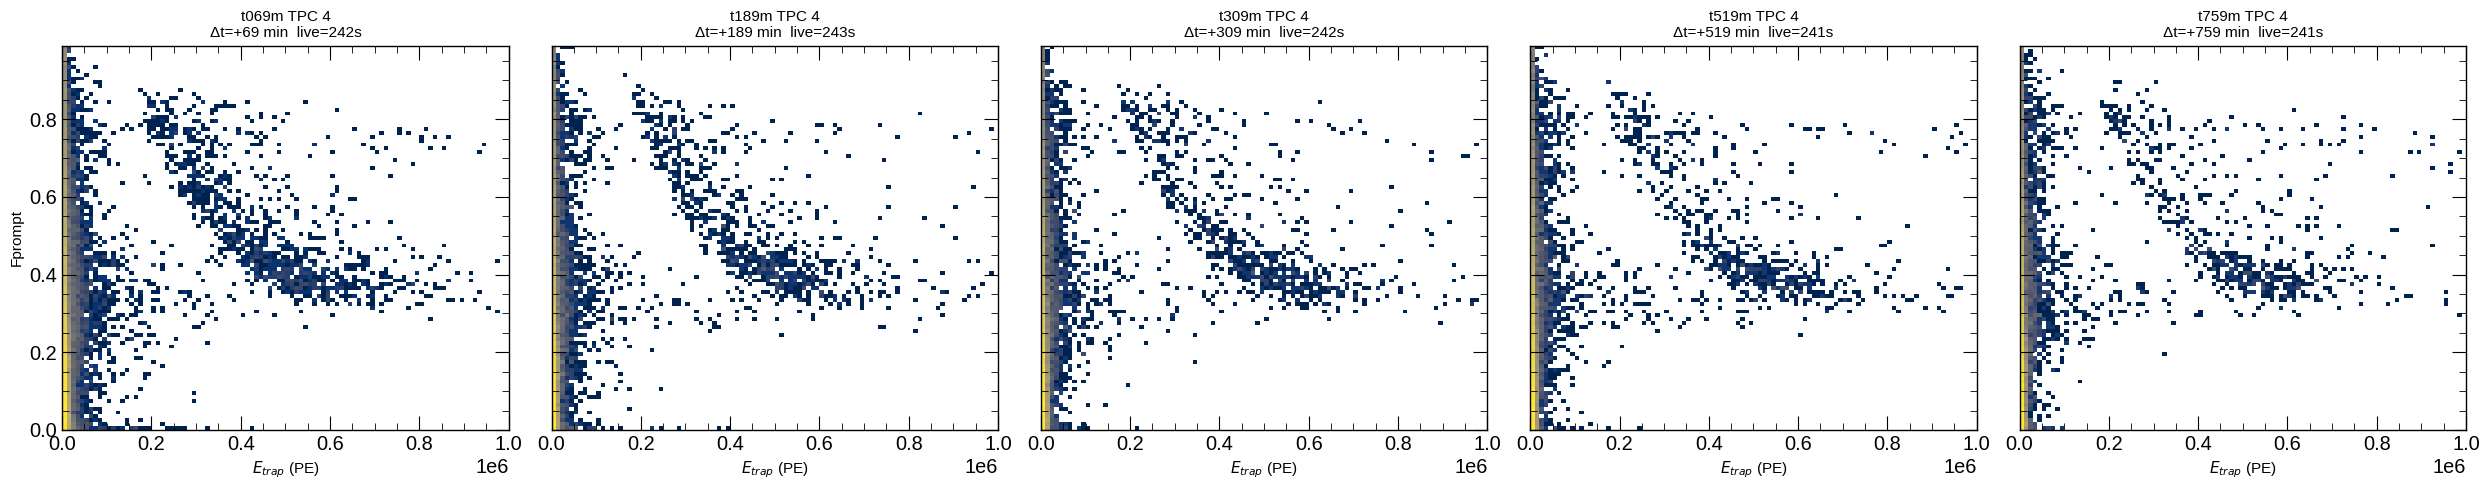

In [13]:
# Compare all decay windows side-by-side (detector type set by DETECTOR variable above)
DETECTOR   = "lcm"   # "acl" or "lcm"
TPC_FILTER = 4    # None = all TPCs, or set to a single TPC int (e.g. 0, 1, …, 7) to restrict

EN_BINS = np.arange(0, 1000000, 10000)
FP_BINS = np.arange(0, 1, 0.01)

def _select(res, det, tpc_filter=None):
    """Return flat fp, en, npe arrays, optionally restricted to one TPC."""
    fp  = res[f"fprompt_{det}"]   # (n_ev, n_traps)
    en  = res[f"energy_{det}"]
    npe = res[f"n_peaks_{det}"]
    tpc_arr = acl_tpc if det == "acl" else lcm_tpc
    if tpc_filter is not None:
        col = tpc_arr == tpc_filter
        fp, en, npe = fp[:, col], en[:, col], npe[:, col]
    return fp.ravel(), en.ravel(), npe.ravel()

n_windows = len(results)
# plot only every other window if there are many, to avoid overwhelming the plot
if n_windows > 10:
    results2 = dict(list(results.items())[::3])
    print(f"More than 10 windows; plotting every third one (total plotted: {len(results2)})")
n_windows = len(results2)
fig, axes = plt.subplots(1, n_windows, figsize=(5 * n_windows, 5),
                         sharey=True, sharex=True)

for ax, (label, res) in zip(axes, results2.items()):
    fp, en, npe = _select(res, DETECTOR, TPC_FILTER)
    en  = en  # gain and PDE correction to get PE
    liv = res["livetime_s"]

    clean = np.isfinite(fp) & np.isfinite(en) & (npe <= 2)
    centre_time = dict(good_windows)[label]
    dt_min = (centre_time - DTG_OFF).total_seconds() / 60

    tpc_label = f" TPC {TPC_FILTER}" if TPC_FILTER is not None else ""
    ax.hist2d(en[clean], fp[clean], bins=[EN_BINS, FP_BINS], norm=LogNorm())
    ax.set_title(f"{label}{tpc_label}\nΔt={dt_min:+.0f} min  live={liv:.0f}s", fontsize=11)
    ax.set_xlabel("$E_{trap}$ (PE)", fontsize=11)
    ax.set_xlim(0, 1000000)

axes[0].set_ylabel("Fprompt", fontsize=11)
plt.tight_layout()
plt.show()


More than 10 windows; plotting every third one (total plotted: 3)


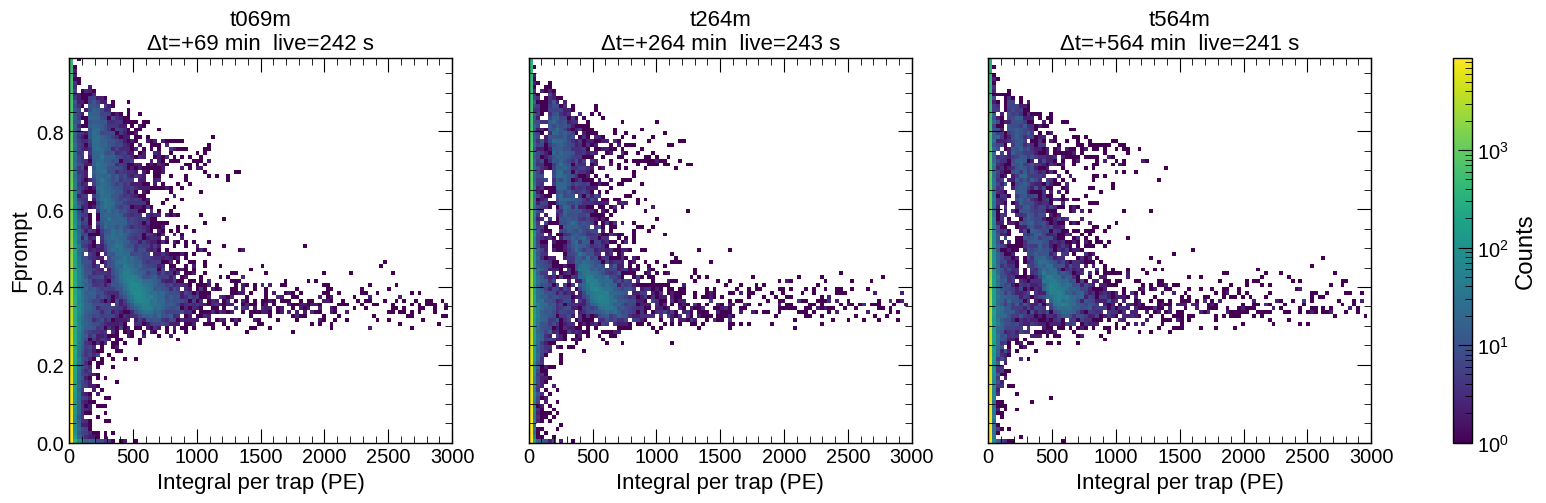

In [44]:
# Compare all decay windows side-by-side (detector type set by DETECTOR variable above)
DETECTOR   = "lcm"   # "acl" or "lcm"
TPC_FILTER = None    # None = all TPCs, or set to a single TPC int (e.g. 0, 1, …, 7) to restrict

EN_BINS = np.arange(0, 3000, 30)
FP_BINS = np.arange(0, 1, 0.01)

# Edit these to match the Ar-41 region you see in the 2D histograms above.
# Ar-41 beta endpoint 2.49 MeV — expect low fprompt (electronic recoil), moderate energy.
AR41_FP_MIN  = 0.55
AR41_FP_MAX  = 0.9
AR41_EN_MIN  = 150   # PE — adjust after looking at the histograms
AR41_EN_MAX  = 1000   # PE

def _select(res, det, tpc_filter=None):
    """Return flat fp, en, npe arrays, optionally restricted to one TPC."""
    fp  = res[f"fprompt_{det}"]   # (n_ev, n_traps)
    en  = res[f"energy_{det}"]
    npe = res[f"n_peaks_{det}"]
    tpc_arr = acl_tpc if det == "acl" else lcm_tpc
    if tpc_filter is not None:
        col = tpc_arr == tpc_filter
        fp, en, npe = fp[:, col], en[:, col], npe[:, col]
    return fp.ravel(), en.ravel(), npe.ravel()

n_windows = len(results)
# plot only every other window if there are many, to avoid overwhelming the plot
if n_windows > 10:
    results2 = dict(list(results.items())[::5])
    print(f"More than 10 windows; plotting every third one (total plotted: {len(results2)})")
n_windows = len(results2)
fig, axes = plt.subplots(1, n_windows, figsize=(7 * n_windows, 5),
                         sharey=True, sharex=True)

for ax, (label, res) in zip(axes, results2.items()):
    fp, en, npe = _select(res, DETECTOR, TPC_FILTER)
    en  = en * 0.004 /4 # gain and PDE correction to get MeV
    liv = res["livetime_s"]

    clean = np.isfinite(fp) & np.isfinite(en) & (npe <= 2)
    centre_time = dict(good_windows)[label]
    dt_min = (centre_time - DTG_OFF).total_seconds() / 60

    tpc_label = f" TPC {TPC_FILTER}" if TPC_FILTER is not None else ""
    ax.hist2d(en[clean], fp[clean], bins=[EN_BINS, FP_BINS], norm=LogNorm(), cmap="viridis")
    ax.set_title(f"{label}{tpc_label}\nΔt={dt_min:+.0f} min  live={liv:.0f} s", fontsize=16)
    ax.set_xlabel("Integral per trap (PE)", fontsize=16)
    ax.set_xlim(0, 3000)
fig.colorbar(axes[0].collections[0], ax=axes, orientation="vertical", label="Counts")
# plot a box around the Ar-41 region
    # ax.axvspan(AR41_EN_MIN, AR41_EN_MAX, AR41_FP_MIN, AR41_FP_MAX, color="red", alpha=0.25, label=f"Fit region ({AR41_EN_MIN}-{AR41_EN_MAX} MeV, {AR41_FP_MIN}-{AR41_FP_MAX} fprompt)")
    # ax.legend(fontsize=10)

axes[0].set_ylabel("Fprompt", fontsize=16)
# plt.tight_layout()
plt.show()

## Define signal region and extract rate vs time for exponential fit

In [15]:

# TPC_FILTER: None = all TPCs, or set to e.g. 0, 1, … for spatial check
# (uses the same _select() helper defined in the 2D histogram cell)

t_min_arr, rate_arr, rate_err_arr = [], [], []

for label, res in results.items():

    centre_time = dict(good_windows)[label]
    dt_min = (centre_time - DTG_OFF).total_seconds() / 60

    fp, en, npe = _select(res, DETECTOR, TPC_FILTER)
    en  = en * 0.004 /4 # gain and PDE correction to get MeV
    liv = res["livetime_s"]

    clean     = np.isfinite(fp) & np.isfinite(en)
    in_region = clean & (fp >= AR41_FP_MIN) & (fp < AR41_FP_MAX) & (en >= AR41_EN_MIN) & (en < AR41_EN_MAX)
    count = in_region.sum()
    rate  = count / liv if liv > 0 else np.nan

    # Background subtraction using cosmics (scaled to same livetime)
    bkg_fp, bkg_en, bkg_npe = _select(bkg_result, DETECTOR, TPC_FILTER)
    bkg_en  = bkg_en
    bkg_liv = bkg_result["livetime_s"]
    bkg_clean = (bkg_npe == 1) & np.isfinite(bkg_fp) & np.isfinite(bkg_en)
    bkg_in    = bkg_clean & (bkg_fp >= AR41_FP_MIN) & (bkg_fp < AR41_FP_MAX) & (bkg_en >= AR41_EN_MIN) & (bkg_en < AR41_EN_MAX)
    bkg_rate  = bkg_in.sum() / bkg_liv if bkg_liv > 0 else 0.0
    rate -= bkg_rate

    rate_err = np.sqrt(count) / liv if liv > 0 else np.nan

    t_min_arr.append(dt_min)
    rate_arr.append(rate)
    rate_err_arr.append(rate_err)
    tpc_label = f" TPC {TPC_FILTER}" if TPC_FILTER is not None else ""
    print(f"{label:15s}{tpc_label}  Δt={dt_min:+7.1f} min  count={count:5d}  rate={rate:.3f} Hz")

t_min_arr    = np.array(t_min_arr)
rate_arr     = np.array(rate_arr)
rate_err_arr = np.array(rate_err_arr)
print(f"Background rate (cosmics): {bkg_rate:.3f} Hz")


t069m            Δt=  +69.0 min  count= 4124  rate=17.026 Hz
t099m            Δt=  +99.0 min  count= 3232  rate=13.286 Hz
t129m            Δt= +129.0 min  count= 3111  rate=12.782 Hz
t189m            Δt= +189.0 min  count= 2589  rate=10.652 Hz
t219m            Δt= +219.0 min  count= 2405  rate=9.899 Hz
t264m            Δt= +264.0 min  count= 2275  rate=9.360 Hz
t309m            Δt= +309.0 min  count= 2078  rate=8.577 Hz
t399m            Δt= +399.0 min  count= 1882  rate=7.821 Hz
t459m            Δt= +459.0 min  count= 1831  rate=7.610 Hz
t519m            Δt= +519.0 min  count= 1781  rate=7.394 Hz
t564m            Δt= +564.0 min  count= 1649  rate=6.843 Hz
t699m            Δt= +699.0 min  count= 1646  rate=6.813 Hz
t759m            Δt= +759.0 min  count= 1596  rate=6.623 Hz
Background rate (cosmics): 0.006 Hz


## Exponential fit to Ar-41 decay curve

Very low PE, full fp       T½=41.1±0.4 min  A=607.07  C=117.885  χ²/ndf=5982.2/10
Low PE, low fp             T½=14.9±0.5 min  A=547.23  C=12.127  χ²/ndf=322.7/10
Low PE, high fp            T½=18.6±2.3 min  A=31.90  C=2.807  χ²/ndf=37.6/10
High PE, low fp            T½=59.9±3.2 min  A=21.47  C=10.581  χ²/ndf=262.7/10
High PE, high fp           T½=104.9±5.3 min  A=13.38  C=5.603  χ²/ndf=40.2/10


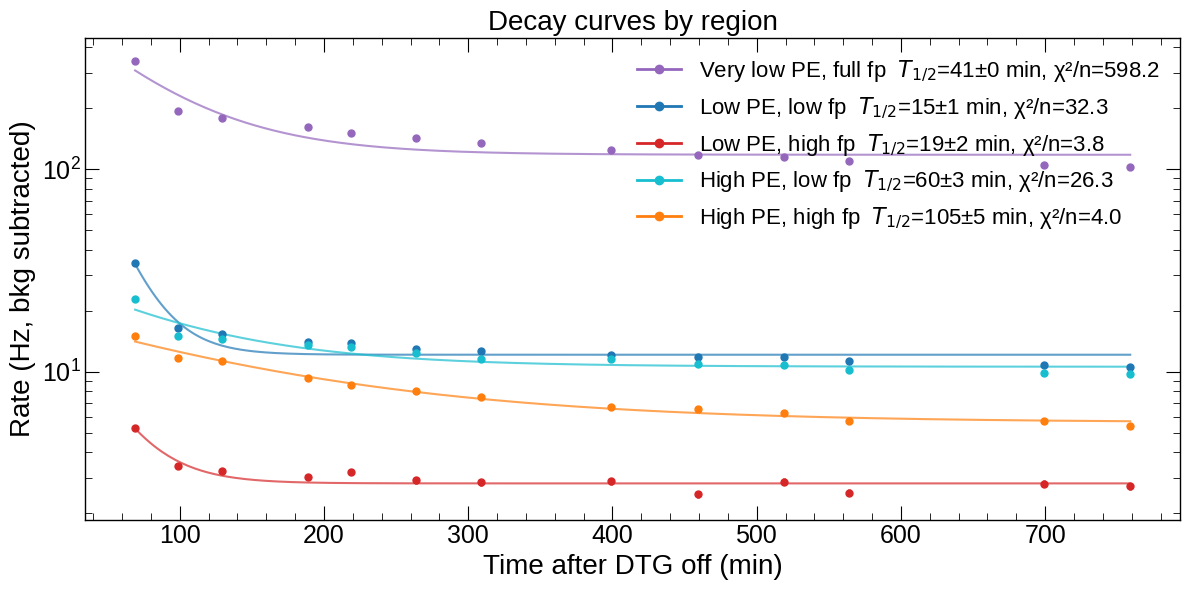

In [16]:
# ── Multi-region decay fits ──────────────────────────────────────────
AR41_HALFLIFE_MIN = AR41_HALF_LIFE

REGIONS = [
    ("Very low PE, full fp",  5,   30,  0.1, 0.9, "tab:purple"),
    ("Low PE, low fp",       35,  250,  0.2, 0.5, "tab:blue"),
    ("Low PE, high fp",      35,  150,  0.55, 0.9, "tab:red"),
    ("High PE, low fp",     350,  800,  0.2, 0.5, "tab:cyan"),
    ("High PE, high fp",    150,  450,  0.55, 0.9, "tab:orange"),
]

def decay_model(t, A, tau, C):
    return A * np.exp(-t * np.log(2) / tau) + C

fig, ax = plt.subplots(figsize=(12, 6))

for reg_label, en_lo, en_hi, fp_lo, fp_hi, color in REGIONS:

    t_arr, r_arr, rerr_arr = [], [], []

    bkg_fp, bkg_en, bkg_npe = _select(bkg_result, DETECTOR, TPC_FILTER)
    bkg_liv = bkg_result["livetime_s"]
    bkg_clean = (bkg_npe == 1) & np.isfinite(bkg_fp) & np.isfinite(bkg_en)
    bkg_in = bkg_clean & (bkg_fp >= fp_lo) & (bkg_fp < fp_hi) & (bkg_en >= en_lo) & (bkg_en < en_hi)
    bkg_rate = bkg_in.sum() / bkg_liv if bkg_liv > 0 else 0.0

    for label, res in results.items():
        centre_time = dict(good_windows)[label]
        dt_min = (centre_time - DTG_OFF).total_seconds() / 60
        fp, en, npe = _select(res, DETECTOR, TPC_FILTER)
        en = en * 0.004 / 4
        liv = res["livetime_s"]
        clean = np.isfinite(fp) & np.isfinite(en)
        in_reg = clean & (fp >= fp_lo) & (fp < fp_hi) & (en >= en_lo) & (en < en_hi)
        count = in_reg.sum()
        rate = count / liv - bkg_rate if liv > 0 else np.nan
        rate_err = np.sqrt(count) / liv if liv > 0 else np.nan
        t_arr.append(dt_min)
        r_arr.append(rate)
        rerr_arr.append(rate_err)

    t_arr = np.array(t_arr)
    r_arr = np.array(r_arr)
    rerr_arr = np.array(rerr_arr)

    fm = np.isfinite(r_arr) & np.isfinite(rerr_arr) & (r_arr > 0)

    # Plot all points
    ax.errorbar(t_arr[fm], r_arr[fm], yerr=rerr_arr[fm],
                fmt="o", color=color, ms=5, zorder=5)

    # Fit excluding the first point
    fm_fit = fm.copy()
    first_idx = np.where(fm_fit)[0]
    if len(first_idx) > 0:
        fm_fit[first_idx[0]] = True

    fit_label = reg_label
    if fm_fit.sum() >= 3:
        try:
            p0 = [r_arr[fm_fit].max(), AR41_HALFLIFE_MIN, 0.0]
            popt, pcov = curve_fit(decay_model, t_arr[fm_fit], r_arr[fm_fit],
                                   sigma=rerr_arr[fm_fit], absolute_sigma=True, p0=p0)
            perr = np.sqrt(np.diag(pcov))
            resid = r_arr[fm_fit] - decay_model(t_arr[fm_fit], *popt)
            chi2 = np.sum((resid / rerr_arr[fm_fit])**2)
            ndf = fm_fit.sum() - len(popt)
            fit_label += fr"  $T_{{1/2}}$={popt[1]:.0f}±{perr[1]:.0f} min, χ²/n={chi2/ndf:.1f}"
            print(f"{reg_label:25s}  T½={popt[1]:.1f}±{perr[1]:.1f} min  "
                  f"A={popt[0]:.2f}  C={popt[2]:.3f}  χ²/ndf={chi2:.1f}/{ndf}")

            t_fine = np.linspace(t_arr[fm].min(), t_arr[fm].max(), 300)
            ax.plot(t_fine, decay_model(t_fine, *popt), color=color, lw=1.5, alpha=0.7)
        except Exception as e:
            print(f"{reg_label:25s}  Fit failed: {e}")
    else:
        print(f"{reg_label:25s}  Not enough points for fit")

    # Dummy for legend
    ax.plot([], [], 'o-', color=color, label=fit_label)

ax.set_xlabel("Time after DTG off (min)", fontsize=20)
ax.set_ylabel("Rate (Hz, bkg subtracted)", fontsize=20)
ax.set_title("Decay curves by region", fontsize=20)
ax.set_yscale("log")
# ax.set_xscale("log")
ax.legend(fontsize=16, loc="upper right")
ax.minorticks_on()
ax.tick_params(direction="in", which="both", labelsize=18)
plt.tight_layout()
plt.show()

Very low PE, full fp       [2-stage] LONG: A=158.840 Hz, T½=1147±30 min
                           SHORT: A=2988.179 Hz, T½=17±0 min
                           Combined χ²/ndf=1405.4/9  (χ²/n=156.2)
Low PE, low fp             [2-stage] LONG: A=14.192 Hz, T½=1764±218 min
                           SHORT: A=1471.455 Hz, T½=11±0 min
                           Combined χ²/ndf=59.9/9  (χ²/n=6.7)
Low PE, high fp            [single] T½=18.6±2.3 min  A=31.90  C=2.807  χ²/ndf=37.6/10
High PE, low fp            [2-stage] LONG: A=13.336 Hz, T½=1629±194 min
                           SHORT: A=139.828 Hz, T½=18±1 min
                           Combined χ²/ndf=78.2/9  (χ²/n=8.7)
High PE, high fp           [single] T½=104.9±5.3 min  A=13.38  C=5.603  χ²/ndf=40.2/10


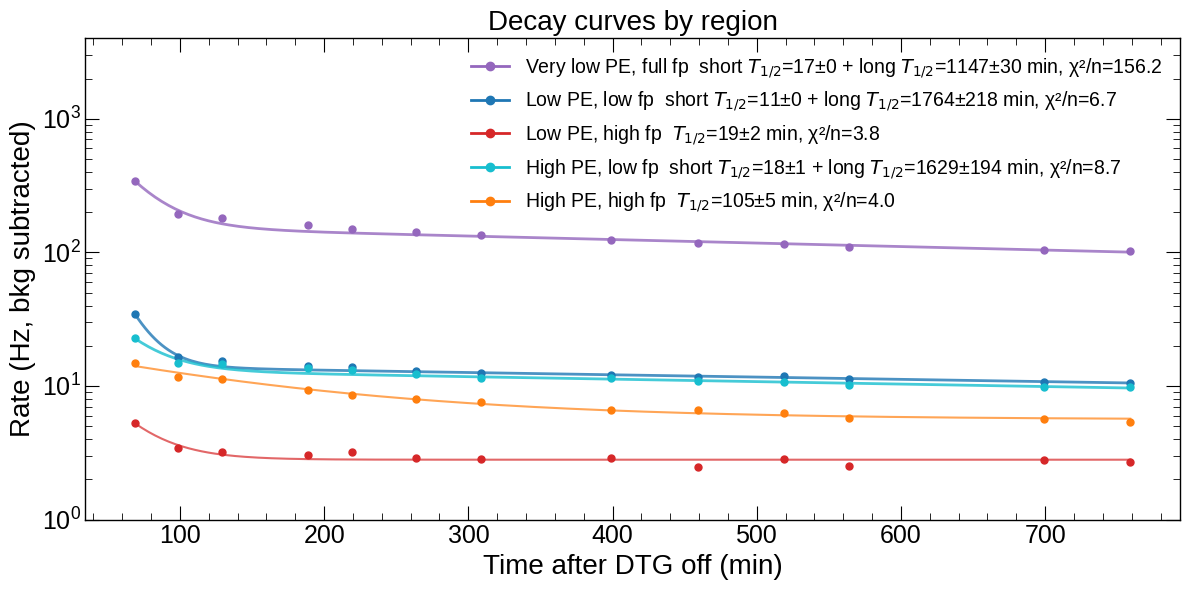

In [17]:
# ── Combined fits: single exp for good χ², two-stage for bad χ² ──────
# Regions with acceptable single-exp fits keep: A*exp(-t*ln2/τ) + C
# Regions with bad χ² get the two-stage decomposition:
#   Stage 1: fit tail (t > T_CUT) → long component
#   Stage 2: subtract from first 6 points → short component

def pure_exp(t, A, tau):
    return A * np.exp(-t * np.log(2) / tau)

T_CUT = 300  # minutes — tail cutoff for two-stage fits

# Regions that had good single-exp χ² (keep single exp + constant)
GOOD_CHI2_REGIONS = {"Low PE, high fp", "High PE, high fp"}

fig, ax = plt.subplots(figsize=(12, 6))

for reg_label, en_lo, en_hi, fp_lo, fp_hi, color in REGIONS:

    # ── Extract rates for this region ──
    t_arr, r_arr, rerr_arr = [], [], []

    bkg_fp, bkg_en, bkg_npe = _select(bkg_result, DETECTOR, TPC_FILTER)
    bkg_liv = bkg_result["livetime_s"]
    bkg_clean = (bkg_npe == 1) & np.isfinite(bkg_fp) & np.isfinite(bkg_en)
    bkg_in = bkg_clean & (bkg_fp >= fp_lo) & (bkg_fp < fp_hi) & (bkg_en >= en_lo) & (bkg_en < en_hi)
    bkg_rate = bkg_in.sum() / bkg_liv if bkg_liv > 0 else 0.0

    for label, res in results.items():
        centre_time = dict(good_windows)[label]
        dt_min = (centre_time - DTG_OFF).total_seconds() / 60
        fp, en, npe = _select(res, DETECTOR, TPC_FILTER)
        en = en * 0.004 / 4
        liv = res["livetime_s"]
        clean = np.isfinite(fp) & np.isfinite(en)
        in_reg = clean & (fp >= fp_lo) & (fp < fp_hi) & (en >= en_lo) & (en < en_hi)
        count = in_reg.sum()
        rate = count / liv - bkg_rate if liv > 0 else np.nan
        rate_err = np.sqrt(count) / liv if liv > 0 else np.nan
        t_arr.append(dt_min)
        r_arr.append(rate)
        rerr_arr.append(rate_err)

    t_arr = np.array(t_arr)
    r_arr = np.array(r_arr)
    rerr_arr = np.array(rerr_arr)
    fm = np.isfinite(r_arr) & np.isfinite(rerr_arr) & (r_arr > 0)

    # Plot all data points
    ax.errorbar(t_arr[fm], r_arr[fm], yerr=rerr_arr[fm],
                fmt="o", color=color, ms=5, zorder=5)

    fit_label = reg_label

    if reg_label in GOOD_CHI2_REGIONS:
        # ════════ Single exponential + constant ════════
        if fm.sum() >= 3:
            try:
                p0 = [r_arr[fm].max(), AR41_HALFLIFE_MIN, 0.0]
                popt, pcov = curve_fit(decay_model, t_arr[fm], r_arr[fm],
                                       sigma=rerr_arr[fm], absolute_sigma=True, p0=p0)
                perr = np.sqrt(np.diag(pcov))
                resid = r_arr[fm] - decay_model(t_arr[fm], *popt)
                chi2 = np.sum((resid / rerr_arr[fm])**2)
                ndf = fm.sum() - len(popt)
                fit_label += fr"  $T_{{1/2}}$={popt[1]:.0f}±{perr[1]:.0f} min, χ²/n={chi2/ndf:.1f}"
                print(f"{reg_label:25s}  [single] T½={popt[1]:.1f}±{perr[1]:.1f} min  "
                      f"A={popt[0]:.2f}  C={popt[2]:.3f}  χ²/ndf={chi2:.1f}/{ndf}")
                t_fine = np.linspace(t_arr[fm].min(), t_arr[fm].max(), 300)
                ax.plot(t_fine, decay_model(t_fine, *popt), color=color, lw=1.5, alpha=0.7)
            except Exception as e:
                print(f"{reg_label:25s}  Single fit failed: {e}")
    else:
        # ════════ Two-stage double exponential ════════
        tail_mask = fm & (t_arr > T_CUT)
        if tail_mask.sum() < 2:
            print(f"{reg_label:25s}  Not enough tail points (need ≥2, got {tail_mask.sum()})")
            ax.plot([], [], 'o-', color=color, label=fit_label)
            continue

        # Stage 1: fit tail → long component
        try:
            p0_long = [r_arr[tail_mask].max(), 300.0]
            popt_long, pcov_long = curve_fit(pure_exp, t_arr[tail_mask], r_arr[tail_mask],
                                             sigma=rerr_arr[tail_mask], absolute_sigma=True,
                                             p0=p0_long)
            perr_long = np.sqrt(np.diag(pcov_long))
            C_long, tau_long = popt_long
            print(f"{reg_label:25s}  [2-stage] LONG: A={C_long:.3f} Hz, "
                  f"T½={tau_long:.0f}±{perr_long[1]:.0f} min")
        except Exception as e:
            print(f"{reg_label:25s}  Long-component fit failed: {e}")
            ax.plot([], [], 'o-', color=color, label=fit_label)
            continue

        # Stage 2: subtract long from first 6 points → short component
        head_indices = np.where(fm)[0][:6]
        head_mask = np.zeros_like(fm)
        head_mask[head_indices] = True

        residual = r_arr[head_mask] - pure_exp(t_arr[head_mask], *popt_long)
        residual_err = rerr_arr[head_mask]
        pos_resid = residual > 0

        if pos_resid.sum() < 2:
            print(f"{' ':25s}  Residual not positive enough for short fit")
            t_fine = np.linspace(t_arr[fm].min(), t_arr[fm].max(), 300)
            ax.plot(t_fine, pure_exp(t_fine, *popt_long), '--', color=color, lw=1.5, alpha=0.5)
            fit_label += fr"  long $T_{{1/2}}$={tau_long:.0f}±{perr_long[1]:.0f} min"
            ax.plot([], [], 'o-', color=color, label=fit_label)
            continue

        try:
            p0_short = [residual[pos_resid].max(), AR41_HALFLIFE_MIN]
            popt_short, pcov_short = curve_fit(pure_exp,
                                               t_arr[head_mask][pos_resid], residual[pos_resid],
                                               sigma=residual_err[pos_resid], absolute_sigma=True,
                                               p0=p0_short)
            perr_short = np.sqrt(np.diag(pcov_short))
            A_short, tau_short = popt_short
            print(f"{' ':25s}  SHORT: A={A_short:.3f} Hz, "
                  f"T½={tau_short:.0f}±{perr_short[1]:.0f} min")
        except Exception as e:
            print(f"{' ':25s}  Short-component fit failed: {e}")
            t_fine = np.linspace(t_arr[fm].min(), t_arr[fm].max(), 300)
            ax.plot(t_fine, pure_exp(t_fine, *popt_long), '--', color=color, lw=1.5, alpha=0.5)
            fit_label += fr"  long $T_{{1/2}}$={tau_long:.0f}±{perr_long[1]:.0f} min"
            ax.plot([], [], 'o-', color=color, label=fit_label)
            continue

        # χ² of combined model against ALL data points
        combined_pred = pure_exp(t_arr[fm], *popt_short) + pure_exp(t_arr[fm], *popt_long)
        resid_all = r_arr[fm] - combined_pred
        chi2 = np.sum((resid_all / rerr_arr[fm])**2)
        ndf = fm.sum() - 4  # 4 free params: A_short, tau_short, C_long, tau_long
        print(f"{' ':25s}  Combined χ²/ndf={chi2:.1f}/{ndf}  (χ²/n={chi2/ndf:.1f})")

        # Plot both components and combined
        t_fine = np.linspace(t_arr[fm].min(), t_arr[fm].max(), 300)
        long_curve = pure_exp(t_fine, *popt_long)
        short_curve = pure_exp(t_fine, *popt_short)
        combined = long_curve + short_curve

        ax.plot(t_fine, combined, '-', color=color, lw=2, alpha=0.8)
        # ax.plot(t_fine, long_curve, '--', color=color, lw=1, alpha=0.4)
        # ax.plot(t_fine, short_curve, ':', color=color, lw=1, alpha=0.4)

        fit_label += (fr"  short $T_{{1/2}}$={tau_short:.0f}±{perr_short[1]:.0f}"
                      fr" + long $T_{{1/2}}$={tau_long:.0f}±{perr_long[1]:.0f} min"
                      fr", χ²/n={chi2/ndf:.1f}")

    ax.plot([], [], 'o-', color=color, label=fit_label)

ax.set_xlabel("Time after DTG off (min)", fontsize=20)
ax.set_ylabel("Rate (Hz, bkg subtracted)", fontsize=20)
ax.set_title("Decay curves by region", fontsize=20)
ax.set_yscale("log")
ax.set_ylim(1, 4e3)
ax.legend(fontsize=14, loc="upper right")
ax.minorticks_on()
ax.tick_params(direction="in", which="both", labelsize=18)
plt.tight_layout()
plt.show()

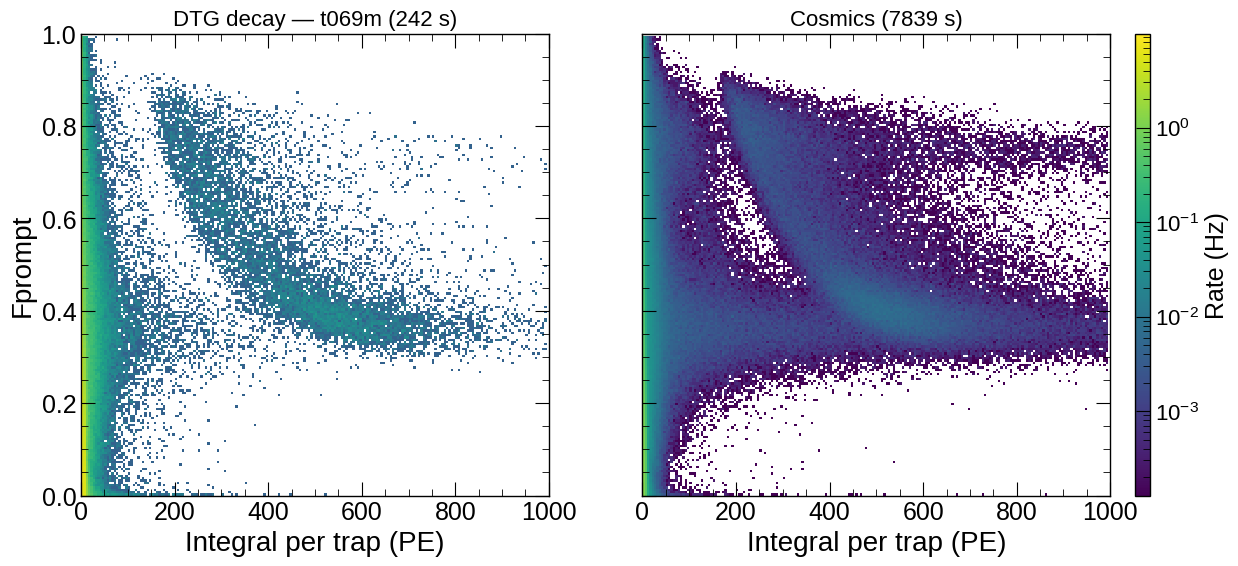

In [32]:
# ── fprompt vs energy: DTG decay vs cosmics (side by side, same colorscale) ───
from matplotlib.patches import Rectangle

# DTG: first time window
first_label, first_res = list(results.items())[0]
fp_dtg, en_dtg, npe_dtg = _select(first_res, DETECTOR, TPC_FILTER)
en_dtg = en_dtg * 0.004 / 4
liv_dtg = first_res["livetime_s"]
clean_dtg = np.isfinite(fp_dtg) & np.isfinite(en_dtg)

# Cosmics
fp_bkg, en_bkg, npe_bkg = _select(bkg_result, DETECTOR, TPC_FILTER)
en_bkg = en_bkg * 0.004 / 4
liv_bkg = bkg_result["livetime_s"]
clean_bkg = np.isfinite(fp_bkg) & np.isfinite(en_bkg)

EN_BINS = np.arange(0, 1000, 5)
FP_BINS = np.arange(0, 1, 0.005)

# Both normalized to rate (Hz)
h_dtg, _, _ = np.histogram2d(en_dtg[clean_dtg], fp_dtg[clean_dtg], bins=[EN_BINS, FP_BINS])
h_dtg = h_dtg / liv_dtg

h_bkg, _, _ = np.histogram2d(en_bkg[clean_bkg], fp_bkg[clean_bkg], bins=[EN_BINS, FP_BINS])
h_bkg = h_bkg / liv_bkg

# Shared color scale
vmin = min(h_dtg[h_dtg > 0].min(), h_bkg[h_bkg > 0].min())
vmax = max(h_dtg.max(), h_bkg.max())
norm = LogNorm(vmin=vmin, vmax=vmax)

h_dtg = np.ma.masked_where(h_dtg == 0, h_dtg)
h_bkg = np.ma.masked_where(h_bkg == 0, h_bkg)

REGIONS = [
    ("Very low PE, full fp",  5,   30,  0.1, 0.9, "tab:purple"),
    ("Low PE, low fp",       35,  250,  0.2, 0.5, "tab:blue"),
    ("Low PE, high fp",      35,  150,  0.55, 0.9, "tab:red"),
    ("High PE, low fp",     350,  800,  0.2, 0.5, "tab:cyan"),
    ("High PE, high fp",    150,  450,  0.55, 0.9, "tab:orange"),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, h, title in [(ax1, h_dtg, f"DTG decay — {first_label} ({liv_dtg:.0f} s)"),
                      (ax2, h_bkg, f"Cosmics ({liv_bkg:.0f} s)")]:
    im = ax.pcolormesh(EN_BINS, FP_BINS, h.T, norm=norm, cmap='viridis')

    # for reg_label, en_lo, en_hi, fp_lo, fp_hi, color in REGIONS:
    #     rect = Rectangle((en_lo, fp_lo), en_hi - en_lo, fp_hi - fp_lo,
    #                       linewidth=2, edgecolor=color, facecolor=color, alpha=0.25)
    #     rect2 = Rectangle((en_lo, fp_lo), en_hi - en_lo, fp_hi - fp_lo,
    #                        linewidth=2, edgecolor=color, facecolor=None, fill=None, alpha=1)
    #     ax.add_patch(rect)
    #     ax.add_patch(rect2)

    ax.set_xlabel("Integral per trap (PE)", fontsize=20)
    ax.set_title(title, fontsize=16)
    ax.set_xlim(0, 1000)
    ax.set_ylim(0, 1)
    ax.minorticks_on()
    ax.tick_params(direction="in", which="both", labelsize=18)

ax1.set_ylabel("Fprompt", fontsize=20)

cb = fig.colorbar(im, ax=[ax1, ax2], pad=0.02, aspect=30)
cb.set_label("Rate (Hz)", fontsize=18)
cb.ax.tick_params(labelsize=16)
# plt.tight_layout()
plt.show()